今まで、ずっと使ってきたJena Climate Datasetに対して、optunaの適用

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler,MinMaxScaler
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch
import math

In [24]:
df=pd.read_csv("jena_climate_2009_2016.csv")
df['day']=pd.to_datetime(df['Date Time'],dayfirst=True)
df.drop("Date Time",axis=1,inplace=True)
df_day = df.resample('D', on='day').mean().reset_index()
df_nan_rows = df_day[df_day.isnull().any(axis=1)]
ideal_range = pd.date_range(start=df_day['day'].min(), end=df_day['day'].max(), freq='D')
df_indexed = df_day.set_index('day').reindex(ideal_range)
missing_dates = df_indexed[df_indexed.isnull().any(axis=1)].index
df_nonan = df_indexed.interpolate(method='linear')
df_p=df_nonan.reset_index().rename({'index':"day"},axis=1)
timestamp_s = df_p.day.map(pd.Timestamp.timestamp) 
day_seconds = 24 * 60 * 60
year_seconds = (365.2425) * day_seconds
df_p['Year_sin'] = np.sin(timestamp_s * (2 * np.pi / year_seconds))
df_p['Year_cos'] = np.cos(timestamp_s * (2 * np.pi / year_seconds))
wd_rad = df_p['wd (deg)'] * np.pi / 180
df_p['Wx'] = df_p['wv (m/s)'] * np.cos(wd_rad)
df_p['Wy'] = df_p['wv (m/s)'] * np.sin(wd_rad)
cols_to_drop = [
    'day', 
    'wv (m/s)', 'max. wv (m/s)', 'wd (deg)',
    'Tpot (K)', 'Tdew (degC)',
    'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)'
]
df_final = df_p.drop(columns=cols_to_drop)
n = len(df_final)
train_df = df_final[0:int(n*0.7)]
val_df = df_final[int(n*0.7):int(n*0.9)]
test_df = df_final[int(n*0.9):]

scaler = StandardScaler()
scaler.fit(train_df)

train_scaled = scaler.transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

print("Trainデータの形状:", train_scaled.shape)
print("Valデータの形状:", val_scaled.shape)
print("Testデータの形状:", test_scaled.shape)
train_df = pd.DataFrame(train_scaled, columns=df_final.columns, index=train_df.index)
val_df = pd.DataFrame(val_scaled, columns=df_final.columns, index=val_df.index)
test_df = pd.DataFrame(test_scaled, columns=df_final.columns, index=test_df.index)

class data_load(Dataset):
    def __init__(self,df,input_width,label_width,shift,label_col=None):
        self.df=df
        self.input_width=input_width
        self.label_width=label_width
        self.total_window_size=input_width+shift
        self.label_columns=label_col
        if label_col is not None:
            col_ind={name:i for i,name in  enumerate(df.columns)}
            self.lab_ind=[col_ind[name] for name in self.label_columns]
        self.data = torch.tensor(df.values.astype('float32'))
    def __len__(self):
        return len(self.data)-self.total_window_size+1
    
    def __getitem__(self, i):
        window=self.data[i:i+self.total_window_size]
        inputs = window[:self.input_width, :]
        label_start = self.total_window_size - self.label_width
        labels = window[label_start:, :]
        if self.label_columns is not None:
            labels=labels[:,self.lab_ind]
        return inputs,labels

def create_dataloader(df, input_width=7, label_width=7, shift=7, batch_size=32, shuffle=False):
    dataset = data_load(
        df=df, 
        input_width=input_width, 
        label_width=label_width, 
        shift=shift, 
        label_col=label_cols  
    )
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    
    return dataloader

label_cols=['T (degC)']
train_loader = create_dataloader(
    df=train_df,       
    input_width=14, 
    label_width=14, 
    shift=14, 
    batch_size=32, 
    shuffle=True
)
val_loader = create_dataloader(
    df=val_df,       
    input_width=14, 
    label_width=14, 
    shift=14, 
    batch_size=32, 
    shuffle=False
)
test_loader = create_dataloader(
    df=test_df,       
    input_width=14, 
    label_width=14, 
    shift=14, 
    batch_size=32, 
    shuffle=False
)

Trainデータの形状: (2046, 8)
Valデータの形状: (584, 8)
Testデータの形状: (293, 8)


以下、各変数における分布のcheck
説明変数も目的変数も似たような分布、正規分布に近いものだと、最適化の際にスムーズに進む。ただ、説明変数に関しては、そこまで気にしなくていい
また、目的変数は、損失関数にMSEを使うならば意識したほうがいい。数学的にMSEは最尤法と同値になるので、残差自体に正規性を仮定しているものだからである。
ただ、今回は、大きく分布の裾が伸びていないので問題はないとおもうが、もし伸びていたらYeo-Johnson変換(今回は値が負もあるので)してもいいかもしれない。

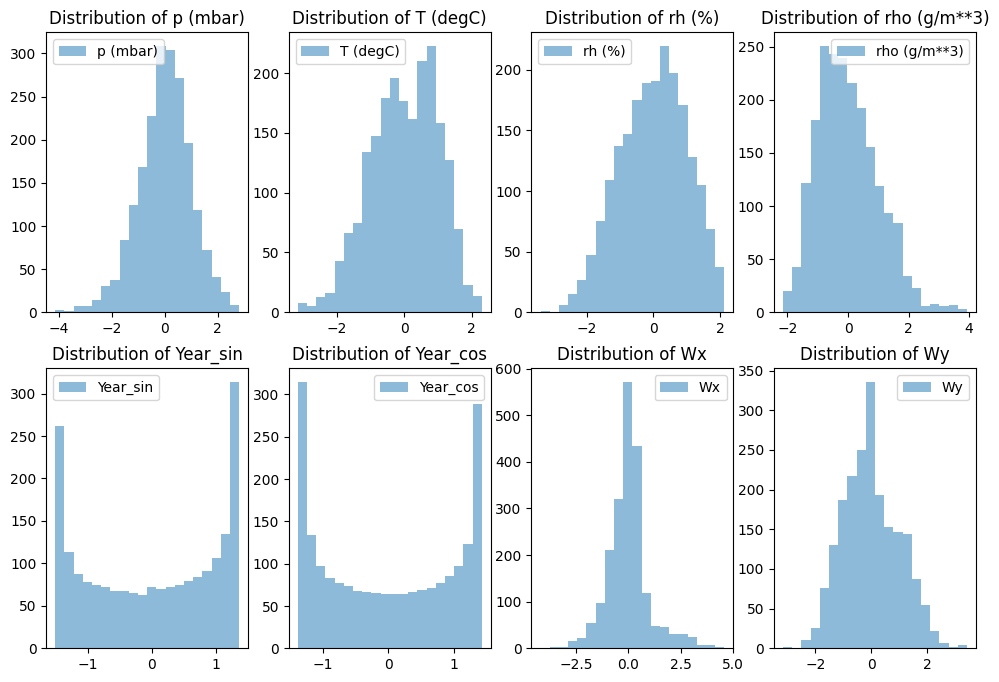

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(12, 8))
axes = axes.flatten()
for i in range(train_df.shape[1]):
    ax = axes[i]
    ax.hist(train_df.iloc[:, i], bins=20, alpha=0.5, label=train_df.columns[i])
    ax.legend()
    ax.set_title(f"Distribution of {train_df.columns[i]}")

 Adversarial Validationの検証をしてみる
時系列データなので、そもそもAUCは多少高くなるのは想定できる
あとは、実際に変数等を減らす意味があるかどうか判断する

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import lightgbm as lgb

In [26]:
df_train_raw = train_df.copy()
df_test_raw = test_df.copy()
df_train_raw['is_test'] = 0
df_test_raw['is_test'] = 1
df_adv = pd.concat([df_train_raw, df_test_raw], axis=0).reset_index(drop=True)
features = [col for col in df_adv.columns if col not in ['is_test', 'T (degC)']]
X_adv = df_adv[features]
y_adv = df_adv['is_test']
X_tr, X_va, y_tr, y_va = train_test_split(
    X_adv, y_adv, test_size=0.3, random_state=999, stratify=y_adv
)


In [28]:
train_dataset = lgb.Dataset(X_tr, label=y_tr)
val_dataset = lgb.Dataset(X_va, label=y_va)

params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'verbosity': -1,
    'random_state': 42
}

model = lgb.train(
    params,
    train_dataset,
    valid_sets=[val_dataset],
    num_boost_round=200,
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
)

# 予測とAUCの算出
preds = model.predict(X_va)
auc_score = roc_auc_score(y_va, preds)
print(f"--- Adversarial Validation 結果 ---")
print(f"ROC-AUC Score: {auc_score:.4f}")

--- Adversarial Validation 結果 ---
ROC-AUC Score: 0.7017


ROC-AUC Score: 0.7017の結果と特徴量の重要度を見てみる
上位に時間に関係するものが来るのは仕方ないかつ、２週間予測なのでこれの変数を消すことはない。
pに関しては見当が必要

In [31]:
importance = model.feature_importance(importance_type='gain')
df_importance = pd.DataFrame({'Feature': features, 'Gain': importance}).sort_values(by='Gain', ascending=False)
df_importance.head(10)

,Feature,Gain
0,p (mbar),497.966811
4,Year_cos,466.286987
3,Year_sin,423.053411
5,Wx,385.765747
2,rho (g/m**3),348.415310
6,Wy,139.725081
1,rh (%),130.370870
